Libraries loaded
Shape       : (1916, 38)
Feature cols: 21
DSR range   : 0.000 ~ 5.000
DSR mean    : 0.3024
=== Part A: Robustness across random seeds ===
Seed=42 | RMSE=0.5596 | MAE=0.2515 | R2=0.5968 | Top3: ['debt_financial', 'h19_pers_income2', 'housing_debt_balance']
Seed=123 | RMSE=0.5377 | MAE=0.2502 | R2=0.5859 | Top3: ['h19_pers_income2', 'debt_financial', 'housing_debt_balance']
Seed=2024 | RMSE=0.4624 | MAE=0.2050 | R2=0.4739 | Top3: ['debt_financial', 'h19_pers_income2', 'h19_cin']
Seed=777 | RMSE=0.5100 | MAE=0.2469 | R2=0.5524 | Top3: ['h19_pers_income2', 'debt_financial', 'h19_cin']
Seed=99 | RMSE=0.5536 | MAE=0.2665 | R2=0.4979 | Top3: ['h19_pers_income2', 'debt_financial', 'h19_cin']

=== Summary across seeds ===
RMSE : 0.5247 +/- 0.0397
MAE  : 0.2440 +/- 0.0231
R2   : 0.5414 +/- 0.0539

=== Part B: SHAP Top-5 Feature Stability across Seeds ===
             feature  appearances stability
      debt_financial            5    Stable
    h19_pers_income2            5    S

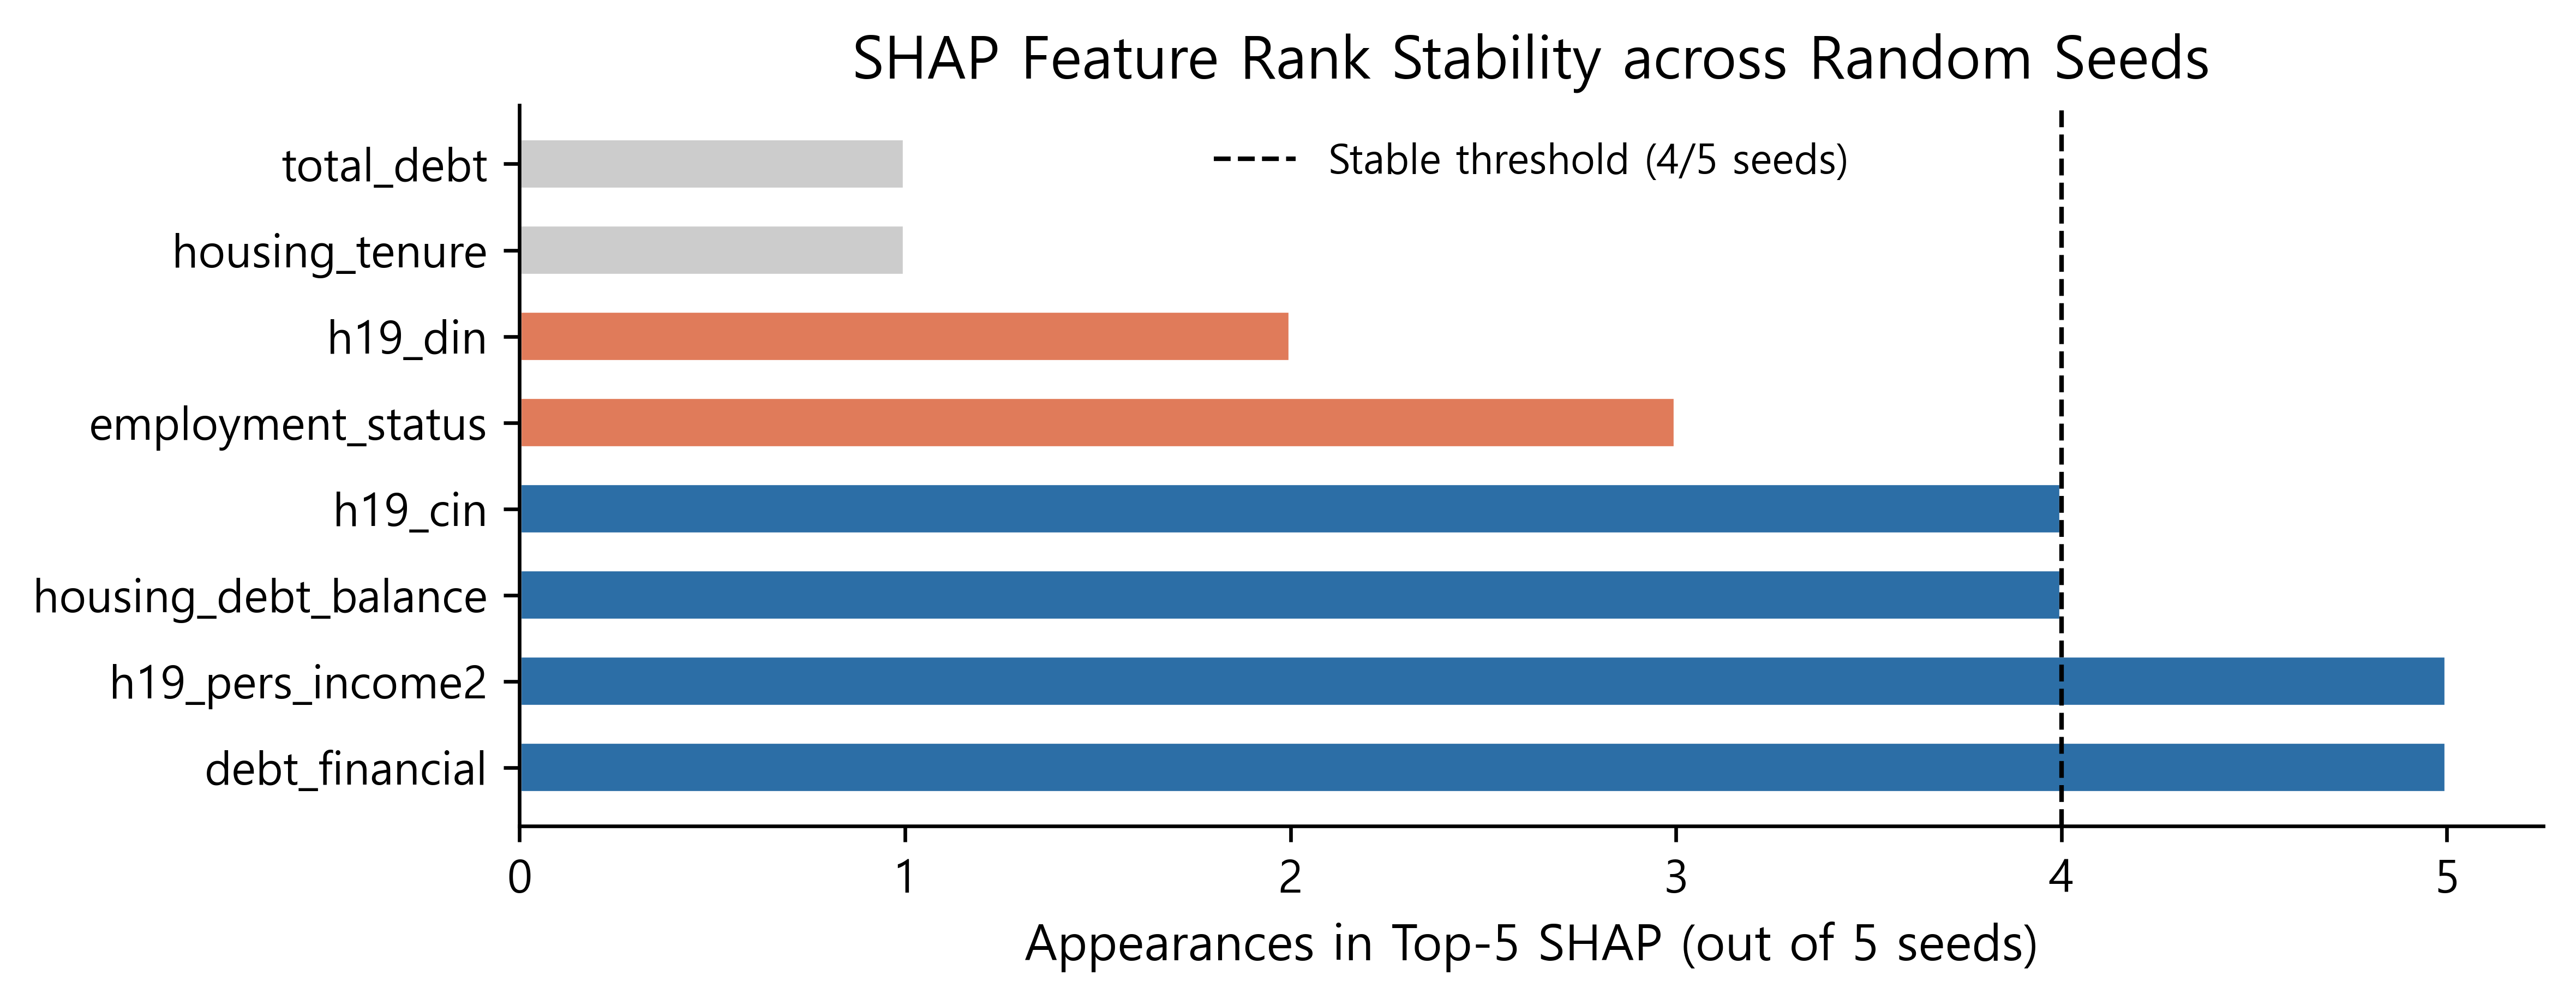

Saved -> outputs/29_shap_stability_reg.png

=== Part C: CF Target Range Sensitivity ===


100%|██████████| 1/1 [00:00<00:00,  2.03it/s]


Range [0.0, 0.1] | success=10 | achieved=10 (100%) | mean changes=4.40


100%|██████████| 1/1 [00:00<00:00,  1.85it/s]


Range [0.0, 0.2] | success=10 | achieved=10 (100%) | mean changes=3.60


100%|██████████| 1/1 [00:00<00:00,  2.67it/s]

Range [0.0, 0.3] | success=10 | achieved=10 (100%) | mean changes=2.50

=== Part C Summary ===
target_range  n_success  n_achieved achievement_rate  mean_changes
  [0.0, 0.1]         10          10             100%           4.4
  [0.0, 0.2]         10          10             100%           3.6
  [0.0, 0.3]         10          10             100%           2.5
Saved -> outputs/sensitivity_seeds_reg.csv
Saved -> outputs/sensitivity_shap_stability_reg.csv
Saved -> outputs/sensitivity_cf_range_reg.csv

All sensitivity analysis outputs saved.


In [2]:
# ═══════════════════════════════════════════════════════════════
# Notebook  : 07_sensitivity_analysis_regression
# Project   : XAI-Driven DSR Prediction Framework for Youth Debt Crisis
# Purpose   : Sensitivity analysis for regression framework
#             Part A: Model robustness across random seeds and train splits
#             Part B: SHAP feature rank stability across seeds
#             Part C: CF target range sensitivity (desired_range variation)
# Data      : youth_debt_preprocessed_regression.csv, model_lgbm_reg.pkl
# Author    :
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import matplotlib
import warnings
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW = dict(dpi=600, bbox_inches='tight', format='png')

print("Libraries loaded")


# ─────────────────────────────────────────────
# Cell 2 | Load preprocessed data & define features
# ─────────────────────────────────────────────
df = pd.read_csv('../data/youth_debt_preprocessed_regression.csv')

DROP_COLS = [
    'h19_pid', 'p19_wgc', 'h19_g4',
    'h19_pers_income3', 'h19_pers_income5',
    'h1906_10', 'dsr_raw', 'dsr_bin',
    'annual_debt_service', 'annual_interest',
    'annual_repayment', 'total_income',
    'h1909_aq7', 'h1909_aq8', 'h1906_aq2',
    'debt_crisis',
]

FEAT_COLS = [c for c in df.columns if c not in DROP_COLS + ['dsr']]

X_full = df[FEAT_COLS].copy()
y_full = df['dsr'].copy()

imp_full = SimpleImputer(strategy='median')
X_imp    = pd.DataFrame(imp_full.fit_transform(X_full), columns=FEAT_COLS)

print(f"Shape       : {df.shape}")
print(f"Feature cols: {len(FEAT_COLS)}")
print(f"DSR range   : {y_full.min():.3f} ~ {y_full.max():.3f}")
print(f"DSR mean    : {y_full.mean():.4f}")


# ─────────────────────────────────────────────
# Cell 3 | Part A: Model robustness across random seeds
# Re-fit LightGBM with 5 different random seeds
# Check stability of RMSE, MAE, R2
# ─────────────────────────────────────────────
SEEDS   = [42, 123, 2024, 777, 99]
partA   = []

print("=== Part A: Robustness across random seeds ===")

for seed in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_imp, y_full, test_size=0.2, random_state=seed)

    model = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=10, random_state=seed, verbose=-1,
    )
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    mae    = mean_absolute_error(y_te, y_pred)
    r2     = r2_score(y_te, y_pred)

    # SHAP top 3
    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X_te)
    mean_shap = pd.Series(np.abs(sv).mean(axis=0),
                          index=FEAT_COLS).sort_values(ascending=False)
    top3      = mean_shap.index[:3].tolist()

    partA.append({
        'seed'    : seed,
        'rmse'    : round(rmse, 4),
        'mae'     : round(mae, 4),
        'r2'      : round(r2, 4),
        'top3_shap': ', '.join(top3),
    })

    print(f"Seed={seed} | RMSE={rmse:.4f} | MAE={mae:.4f} "
          f"| R2={r2:.4f} | Top3: {top3}")

partA_df = pd.DataFrame(partA)
print("\n=== Summary across seeds ===")
print(f"RMSE : {partA_df['rmse'].mean():.4f} +/- {partA_df['rmse'].std():.4f}")
print(f"MAE  : {partA_df['mae'].mean():.4f} +/- {partA_df['mae'].std():.4f}")
print(f"R2   : {partA_df['r2'].mean():.4f} +/- {partA_df['r2'].std():.4f}")


# ─────────────────────────────────────────────
# Cell 4 | Part B: SHAP top-5 feature rank stability
# Check if top features are consistent across seeds
# ─────────────────────────────────────────────
from collections import Counter

# Count how many times each feature appears in top-5 across seeds
top5_all = []
for seed in SEEDS:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_imp, y_full, test_size=0.2, random_state=seed)

    model = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        min_child_samples=10, random_state=seed, verbose=-1,
    )
    model.fit(X_tr, y_tr)

    explainer = shap.TreeExplainer(model)
    sv        = explainer.shap_values(X_te)
    mean_shap = pd.Series(np.abs(sv).mean(axis=0),
                          index=FEAT_COLS).sort_values(ascending=False)
    top5_all.extend(mean_shap.index[:5].tolist())

top5_freq = Counter(top5_all)
top5_df   = pd.DataFrame(top5_freq.items(),
                          columns=['feature', 'appearances'])\
              .sort_values('appearances', ascending=False)\
              .reset_index(drop=True)
top5_df['stability'] = top5_df['appearances'].apply(
    lambda x: 'Stable' if x >= 4 else ('Moderate' if x >= 2 else 'Unstable'))

print("\n=== Part B: SHAP Top-5 Feature Stability across Seeds ===")
print(top5_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, max(3, len(top5_df) * 0.4)))
colors_stab = ['#2c6ea6' if s == 'Stable'
               else ('#e07b5a' if s == 'Moderate' else '#cccccc')
               for s in top5_df['stability']]
ax.barh(top5_df['feature'], top5_df['appearances'],
        color=colors_stab, edgecolor='white', height=0.6)
ax.axvline(4, color='black', linestyle='--', lw=1.0,
           label='Stable threshold (4/5 seeds)')
ax.set_xlabel('Appearances in Top-5 SHAP (out of 5 seeds)')
ax.set_title('SHAP Feature Rank Stability across Random Seeds')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/29_shap_stability_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/29_shap_stability_reg.png")


# ─────────────────────────────────────────────
# Cell 5 | Part C: CF target range sensitivity
# How does DiCE CF achievement rate change
# across different desired_range settings?
# ─────────────────────────────────────────────
import dice_ml
from dice_ml import Dice

lgbm_main = joblib.load('../outputs/model_lgbm_reg.pkl')
X_test    = pd.read_csv('../data/X_test_reg.csv')
y_test    = pd.read_csv('../data/y_test_reg.csv').squeeze()

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

# High-DSR cases
high_idx = y_test_r[y_test_r >= 0.4].index.tolist()[:10]

# Build DiCE interfaces
X_train_dice = pd.read_csv('../data/X_train_reg.csv').astype(float)
y_train_dice = pd.read_csv('../data/y_train_reg.csv').squeeze().astype(float)
df_train_dice = X_train_dice.copy()
df_train_dice['dsr'] = y_train_dice.values

data_iface = dice_ml.Data(
    dataframe=df_train_dice,
    continuous_features=FEAT_COLS,
    outcome_name='dsr'
)
model_iface = dice_ml.Model(
    model=lgbm_main, backend='sklearn', model_type='regressor')
dice_exp = Dice(data_iface, model_iface, method='random')

# Test 3 different desired_range settings
TARGET_RANGES = [
    [0.0, 0.1],
    [0.0, 0.2],
    [0.0, 0.3],
]

partC = []
print("\n=== Part C: CF Target Range Sensitivity ===")

for target_range in TARGET_RANGES:
    n_success  = 0
    n_achieved = 0
    total_changes = []

    for idx in high_idx:
        instance  = X_test_r.iloc[[idx]].copy().astype(float)
        pred_orig = float(lgbm_main.predict(instance)[0])

        try:
            cf_obj  = dice_exp.generate_counterfactuals(
                instance, total_CFs=1,
                desired_range=target_range)
            cf_feats = cf_obj.cf_examples_list[0].final_cfs_df
            if cf_feats is None or len(cf_feats) == 0:
                continue

            cf_feats  = cf_feats.drop(columns=['dsr'], errors='ignore')
            pred_cf   = float(lgbm_main.predict(cf_feats.iloc[[0]])[0])
            diff_mask = (instance.iloc[0].values != cf_feats.iloc[0].values)
            n_changes = int(diff_mask.sum())

            n_success += 1
            total_changes.append(n_changes)

            if target_range[0] <= pred_cf <= target_range[1]:
                n_achieved += 1

        except Exception:
            continue

    achieve_rate = n_achieved / len(high_idx) if len(high_idx) > 0 else 0
    mean_changes = np.mean(total_changes) if total_changes else np.nan

    partC.append({
        'target_range'     : f"[{target_range[0]}, {target_range[1]}]",
        'n_success'        : n_success,
        'n_achieved'       : n_achieved,
        'achievement_rate' : f"{achieve_rate:.0%}",
        'mean_changes'     : round(mean_changes, 2),
    })

    print(f"Range {target_range} | success={n_success} "
          f"| achieved={n_achieved} ({achieve_rate:.0%}) "
          f"| mean changes={mean_changes:.2f}")

partC_df = pd.DataFrame(partC)
print("\n=== Part C Summary ===")
print(partC_df.to_string(index=False))


# ─────────────────────────────────────────────
# Cell 6 | Save all sensitivity results
# ─────────────────────────────────────────────
partA_df.to_csv('../outputs/sensitivity_seeds_reg.csv',
                index=False, encoding='utf-8-sig')
top5_df.to_csv('../outputs/sensitivity_shap_stability_reg.csv',
               index=False, encoding='utf-8-sig')
partC_df.to_csv('../outputs/sensitivity_cf_range_reg.csv',
                index=False, encoding='utf-8-sig')

print("Saved -> outputs/sensitivity_seeds_reg.csv")
print("Saved -> outputs/sensitivity_shap_stability_reg.csv")
print("Saved -> outputs/sensitivity_cf_range_reg.csv")
print("\nAll sensitivity analysis outputs saved.")